https://www.kaggle.com/datasets/redwankarimsony/hackerearth-employee-burnout-challenge

# **Desafio de Burnout dos Funcionários da HackerEarth**

**Sobre o conjunto de dados**

**Contexto**

O Dia Mundial da Saúde Mental é celebrado em 10 de outubro de cada ano. O objetivo deste dia é aumentar a conscientização sobre questões de saúde mental em todo o mundo e mobilizar esforços em apoio à saúde mental. De acordo com uma pesquisa anônima, cerca de 450 milhões de pessoas vivem com transtornos mentais, que podem ser uma das principais causas de problemas de saúde e incapacidade em todo o mundo. Você é um engenheiro de Machine Learning em uma empresa. Sua tarefa é entender e observar a saúde mental de todos os funcionários da empresa. Portanto, você precisa prever a taxa de burnout dos funcionários com base nas características fornecidas, ajudando assim a empresa a tomar as medidas apropriadas para seus colaboradores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

# EAD

In [2]:
#Primeiras linhas do treino
print(train.head())

                Employee ID Date of Joining  Gender Company Type  \
0  fffe32003000360033003200      2008-09-30  Female      Service   
1      fffe3700360033003500      2008-11-30    Male      Service   
2  fffe31003300320037003900      2008-03-10  Female      Product   
3  fffe32003400380032003900      2008-11-03    Male      Service   
4  fffe31003900340031003600      2008-07-24  Female      Service   

  WFH Setup Available  Designation  Resource Allocation  Mental Fatigue Score  \
0                  No          2.0                  3.0                   3.8   
1                 Yes          1.0                  2.0                   5.0   
2                 Yes          2.0                  NaN                   5.8   
3                 Yes          1.0                  1.0                   2.6   
4                  No          3.0                  7.0                   6.9   

   Burn Rate  
0       0.16  
1       0.36  
2       0.49  
3       0.20  
4       0.52  


In [3]:
#Visão Geral e Limpeza
#Informações gerais
print(train.info())

#Checando valores nulos
print(train.isnull().sum())

#Removendo linhas com Burn Rate ausente (nosso alvo)
train = train.dropna(subset=['Burn Rate'])

#Preenchendo valores nulos numéricos com a mediana (estratégia simples)
train['Resource Allocation'] = train['Resource Allocation'].fillna(train['Resource Allocation'].median())
train['Mental Fatigue Score'] = train['Mental Fatigue Score'].fillna(train['Mental Fatigue Score'].median())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB
None
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64


        Designation  Resource Allocation  Mental Fatigue Score     Burn Rate
count  21626.000000         21626.000000          21626.000000  21626.000000
mean       2.178766             4.455239              5.745154      0.452005
std        1.135428             1.990000              1.833016      0.198226
min        0.000000             1.000000              0.000000      0.000000
25%        1.000000             3.000000              4.700000      0.310000
50%        2.000000             4.000000              5.900000      0.450000
75%        3.000000             6.000000              6.900000      0.590000
max        5.000000            10.000000             10.000000      1.000000


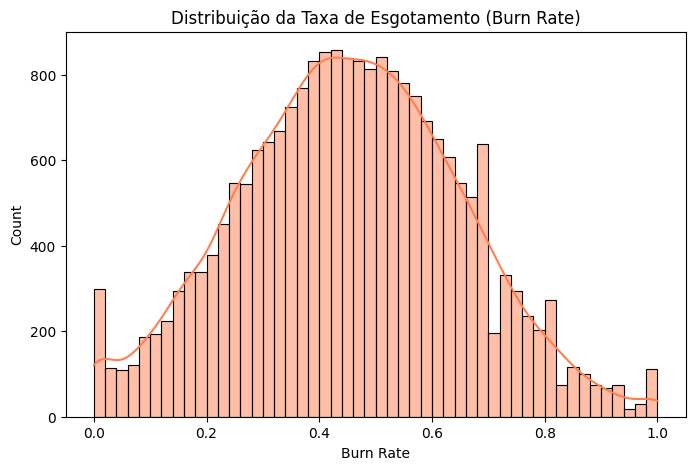

In [4]:
#Análise Estatística e Distribuição (Burn Rate)
#Estatísticas descritivas
print(train.describe())

#Distribuição do Burn Rate
plt.figure(figsize=(8, 5))
sns.histplot(train['Burn Rate'], kde=True, color='coral')
plt.title('Distribuição da Taxa de Esgotamento (Burn Rate)')
plt.show()

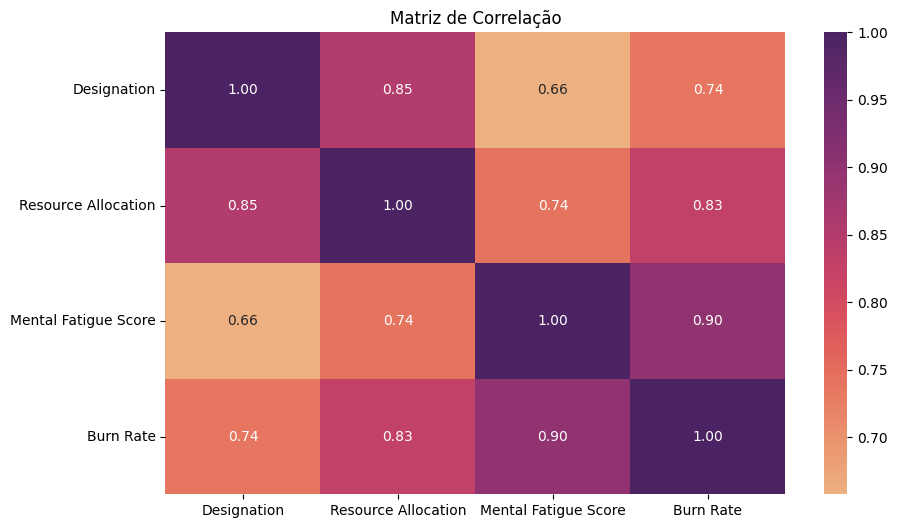

In [5]:
#Análise de Correlação 
#Quais fatores (Designação, Alocação de Recursos, Fadiga Mental) mais influenciam o esgotamento.
#Correlação entre variáveis numéricas
corr_matrix = train.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='flare', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

O Mental Fatigue Score apresenta uma correlação altíssima com o Burn Rate, indicando que a saúde mental é o principal preditor.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3412\3128101442.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WFH Setup Available', y='Burn Rate', data=train, palette='Set2')


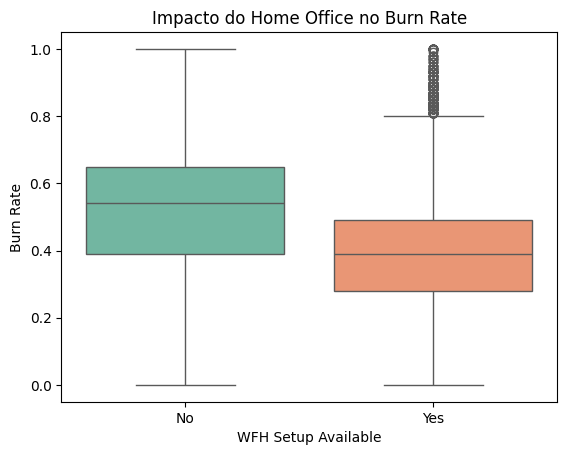

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3412\3128101442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender', y='Burn Rate', data=train, palette='flare')


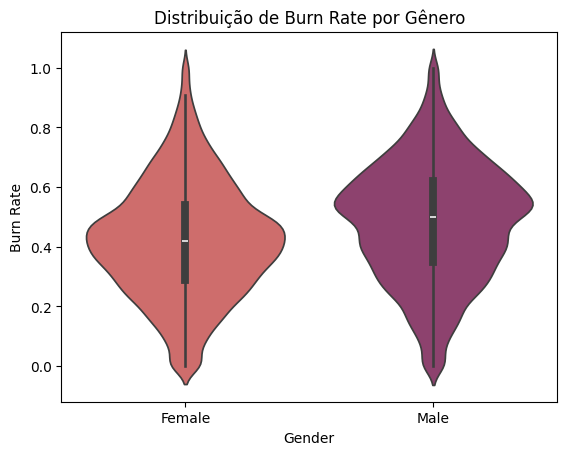

In [6]:
#Comparação por Categorias
#O ambiente de trabalho (Home Office) ou o gênero influenciam o esgotamento?
#Burn Rate vs WFH Setup
sns.boxplot(x='WFH Setup Available', y='Burn Rate', data=train, palette='Set2')
plt.title('Impacto do Home Office no Burn Rate')
plt.show()

#Burn Rate vs Gênero
sns.violinplot(x='Gender', y='Burn Rate', data=train, palette='flare')
plt.title('Distribuição de Burn Rate por Gênero')
plt.show()

Fadiga Mental: É o fator mais crítico. Quanto maior o cansaço mental, quase linearmente maior é o Burn Rate.

Recursos: Funcionários com mais recursos alocados (Resource Allocation) tendem a ter níveis maiores de estresse.

WFH: Ter uma estrutura de trabalho remoto disponível geralmente reduz levemente a média de esgotamento.

# ML

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#PRÉ-PROCESSAMENTO
def limpar_dados(df):
    df_c = df.copy()
    
    #Transformar data em "Dias de Antiguidade"
    df_c['Date of Joining'] = pd.to_datetime(df_c['Date of Joining'])
    data_ref = df_c['Date of Joining'].max()
    df_c['Days_Joined'] = (data_ref - df_c['Date of Joining']).dt.days
    
    #Converter categorias em números (Label Encoding manual)
    df_c['Gender'] = df_c['Gender'].map({'Female': 0, 'Male': 1})
    df_c['Company Type'] = df_c['Company Type'].map({'Service': 0, 'Product': 1})
    df_c['WFH Setup Available'] = df_c['WFH Setup Available'].map({'No': 0, 'Yes': 1})
    
    #Preencher valores nulos com a média (para não perder dados no teste)
    df_c['Resource Allocation'] = df_c['Resource Allocation'].fillna(df_c['Resource Allocation'].mean())
    df_c['Mental Fatigue Score'] = df_c['Mental Fatigue Score'].fillna(df_c['Mental Fatigue Score'].mean())
    
    return df_c


#Nota: No treino, remover linhas onde o alvo (Burn Rate) é nulo
train_clean = limpar_dados(train.dropna(subset=['Burn Rate']))
test_clean = limpar_dados(test)

#SELEÇÃO DE VARIÁVEIS
features = ['Gender', 'Company Type', 'WFH Setup Available', 'Designation', 
            'Resource Allocation', 'Mental Fatigue Score', 'Days_Joined']

X = train_clean[features]
y = train_clean['Burn Rate']

#TREINAMENTO
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

#AVALIAÇÃO
y_pred = modelo.predict(X_val)
print(f"Qualidade do Modelo (R²): {r2_score(y_val, y_pred):.4f}")
print(f"Erro Médio (MSE): {mean_squared_error(y_val, y_pred):.4f}")

#PREDIÇÃO FINAL (SUBMISSÃO)
predicoes_finais = modelo.predict(test_clean[features])

meu_submission = pd.DataFrame({
    'Employee ID': test['Employee ID'],
    'Burn Rate': predicoes_finais
})

#Burn Rate não pode ser menor que 0 nem maior que 1
meu_submission['Burn Rate'] = meu_submission['Burn Rate'].clip(0, 1)

#Mostrando o resultado
print("\nPrimeiras linhas da submissão:")
print(meu_submission.head())

Qualidade do Modelo (R²): 0.8679
Erro Médio (MSE): 0.0050

Primeiras linhas da submissão:
                Employee ID  Burn Rate
0  fffe31003300390039003000   0.603882
1  fffe31003300310037003800   0.317169
2  fffe33003400380035003900   0.401050
3      fffe3100370039003200   0.438295
4  fffe32003600390036003700   0.517441


C:\Users\Usuário\AppData\Local\Temp\ipykernel_3412\2552775859.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Atributo', data=importancias, palette='flare')


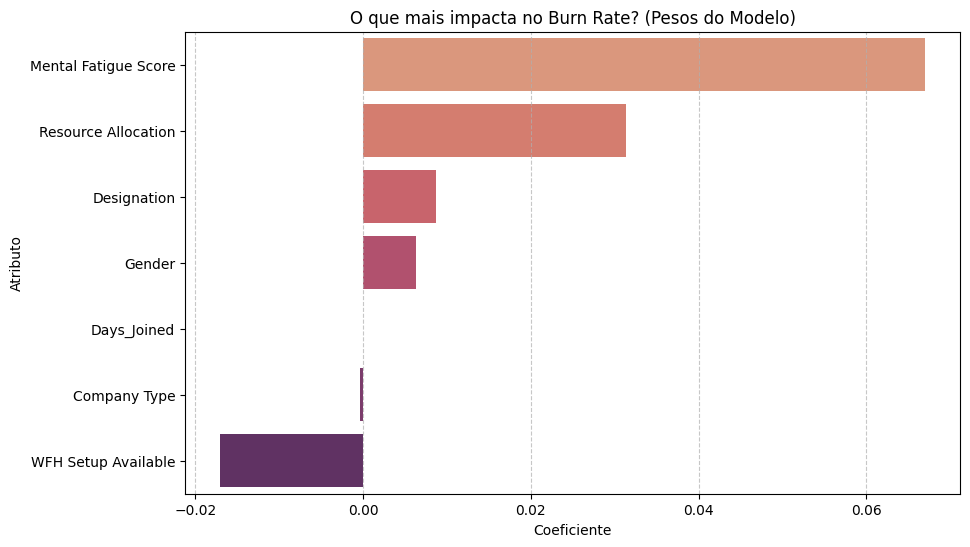

               Atributo  Coeficiente
5  Mental Fatigue Score     0.066982
4   Resource Allocation     0.031312
3           Designation     0.008741
0                Gender     0.006276
6           Days_Joined     0.000007
1          Company Type    -0.000318
2   WFH Setup Available    -0.017033


In [8]:
#Analisando a Importância das Variáveis (Pesos)
importancias = pd.DataFrame({
    'Atributo': features,
    'Coeficiente': modelo.coef_
}).sort_values(by='Coeficiente', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Atributo', data=importancias, palette='flare')
plt.title('O que mais impacta no Burn Rate? (Pesos do Modelo)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(importancias)

O Mental Fatigue Score é o fator mais relevante para o funcionário ter o burnout, seguido pela carga de trabalho (Resource Allocation).

O WFH Setup Available tem um coeficiente negativo (-0.017), o que confirma estatisticamente que ter suporte para Home Office ajuda a reduzir o esgotamento.

In [9]:
from sklearn.ensemble import RandomForestRegressor

#Configurando o modelo (usando 100 árvores para um bom equilíbrio)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

#Treinando (usando os mesmos X_train e y_train do código anterior)
rf_model.fit(X_train, y_train)

#Avaliando o novo modelo
y_pred_rf = rf_model.predict(X_val)
r2_rf = r2_score(y_val, y_pred_rf)
mse_rf = mean_squared_error(y_val, y_pred_rf)

print(f"Novo R² (Random Forest): {r2_rf:.4f}")
print(f"Novo MSE (Random Forest): {mse_rf:.4f}")

#Comparação de Importância
rf_importances = pd.DataFrame({
    'Atributo': features,
    'Importância': rf_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

print("\nImportância das Variáveis no Random Forest:")
print(rf_importances)

Novo R² (Random Forest): 0.8900
Novo MSE (Random Forest): 0.0042

Importância das Variáveis no Random Forest:
               Atributo  Importância
5  Mental Fatigue Score     0.819350
4   Resource Allocation     0.092639
6           Days_Joined     0.057317
3           Designation     0.012746
2   WFH Setup Available     0.006213
0                Gender     0.005969
1          Company Type     0.005768


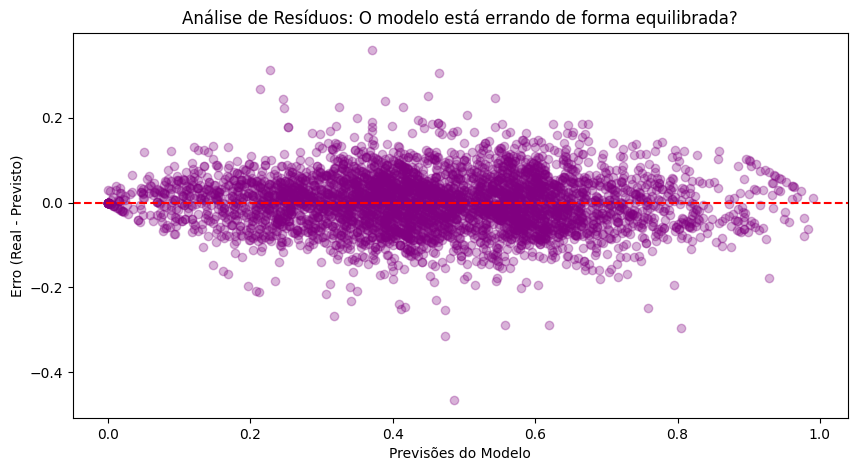

In [10]:
#Verificação de Resíduos (Check-up do Modelo)
#Calculando os erros (resíduos)
residuos = y_val - y_pred_rf

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_rf, residuos, alpha=0.3, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Previsões do Modelo')
plt.ylabel('Erro (Real - Previsto)')
plt.title('Análise de Resíduos: O modelo está errando de forma equilibrada?')
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

#Definindo parâmetros para testar
param_grid = {
    'n_estimators': [100, 200],          
    'max_depth': [10, 20, None],         
    'min_samples_split': [2, 5],         
    'max_features': ['sqrt', 'log2']     
}

#Configurando a busca (usando 3 divisões de validação cruzada)
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, 
    n_jobs=-1, 
    scoring='r2',
    verbose=2
)

#Executando a busca
grid_search.fit(X_train, y_train)

#Melhores resultados
print(f"Melhores Parâmetros: {grid_search.best_params_}")
print(f"Melhor Score no Treino: {grid_search.best_score_:.4f}")

#Testando o modelo campeão nos dados de validação
melhor_rf = grid_search.best_estimator_
y_pred_otimizado = melhor_rf.predict(X_val)

print(f"R² Final Otimizado: {r2_score(y_val, y_pred_otimizado):.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Melhores Parâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Melhor Score no Treino: 0.9001
R² Final Otimizado: 0.8989


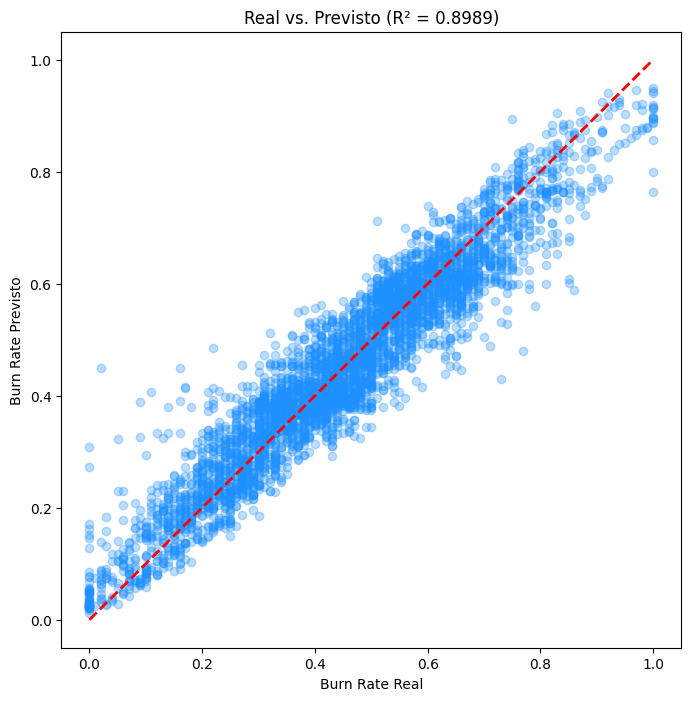

In [12]:
#Visualizando a Performance Final
plt.figure(figsize=(8, 8))
plt.scatter(y_val, y_pred_otimizado, alpha=0.3, color='dodgerblue')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--') 
plt.xlabel('Burn Rate Real')
plt.ylabel('Burn Rate Previsto')
plt.title('Real vs. Previsto (R² = 0.8989)')
plt.show()

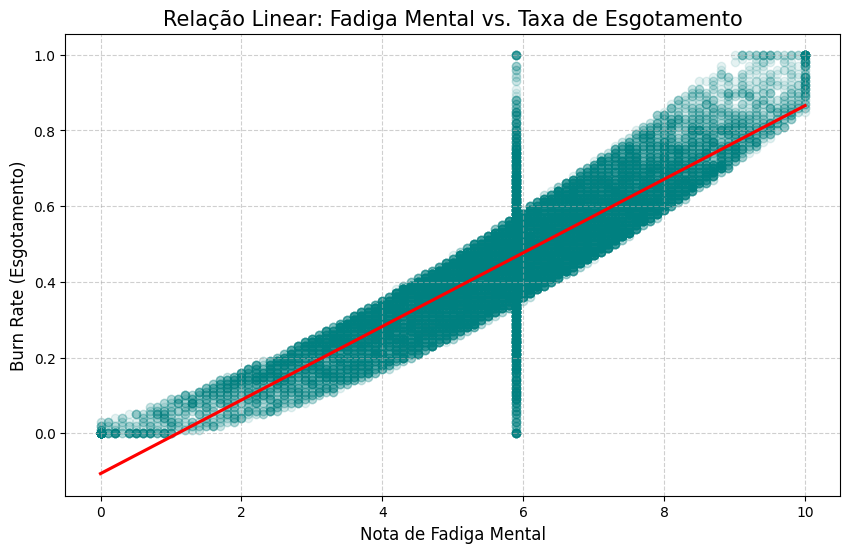

In [13]:
#Gráfico de Dispersão: Fadiga Mental vs. Burnout
plt.figure(figsize=(10, 6))
sns.regplot(x='Mental Fatigue Score', y='Burn Rate', data=train_clean, 
            scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Relação Linear: Fadiga Mental vs. Taxa de Esgotamento', fontsize=15)
plt.xlabel('Nota de Fadiga Mental', fontsize=12)
plt.ylabel('Burn Rate (Esgotamento)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3412\2817953580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WFH Setup Available', y='Burn Rate', data=train, palette='Set2')


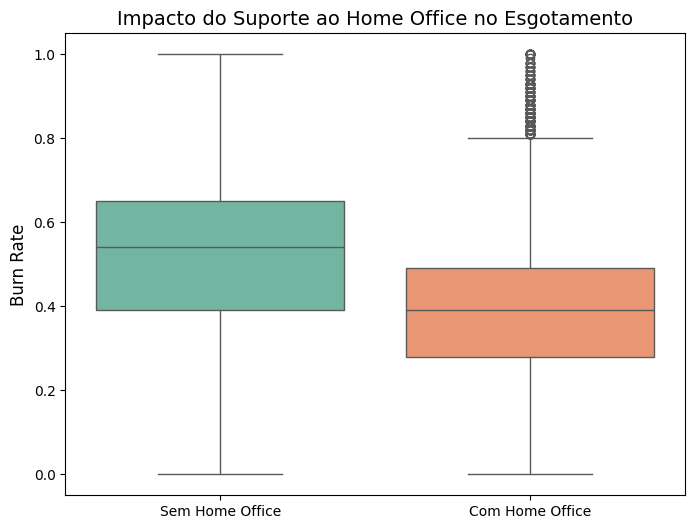

In [14]:
#Comparativo: O Impacto do Home Office (WFH)
plt.figure(figsize=(8, 6))
sns.boxplot(x='WFH Setup Available', y='Burn Rate', data=train, palette='Set2')
plt.title('Impacto do Suporte ao Home Office no Esgotamento', fontsize=14)
plt.xticks([0, 1], ['Sem Home Office', 'Com Home Office'])
plt.ylabel('Burn Rate', fontsize=12)
plt.xlabel('')
plt.show()

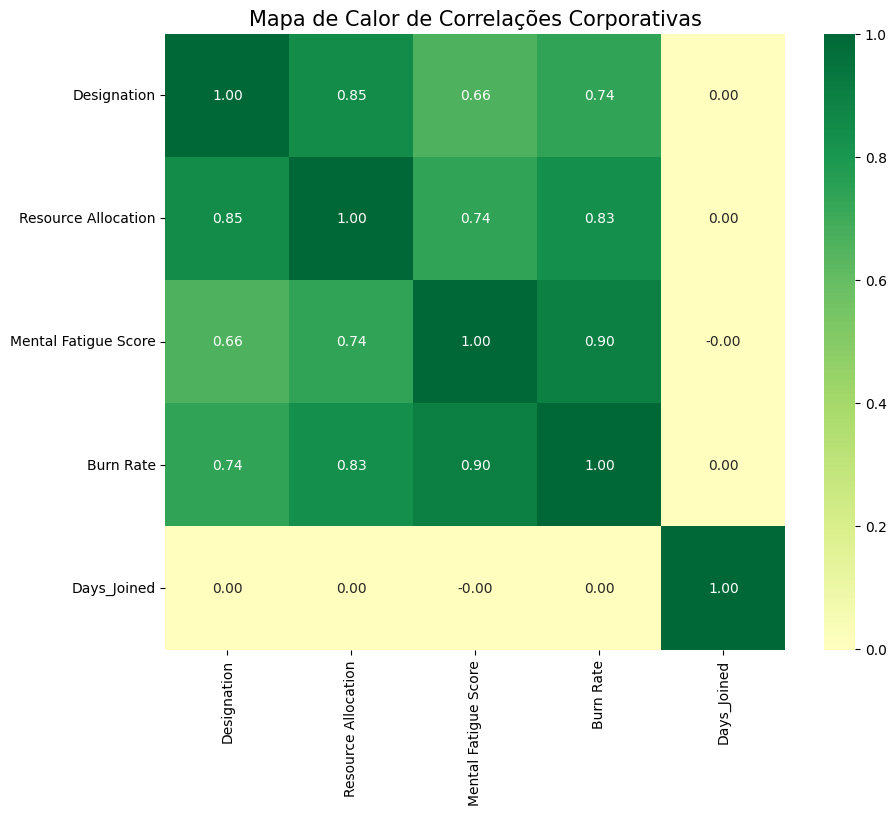

In [15]:
#Matriz de Correlação
plt.figure(figsize=(10, 8))
cols_visual = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate', 'Days_Joined']
corr = train_clean[cols_visual].corr()

sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Mapa de Calor de Correlações Corporativas', fontsize=15)
plt.show()

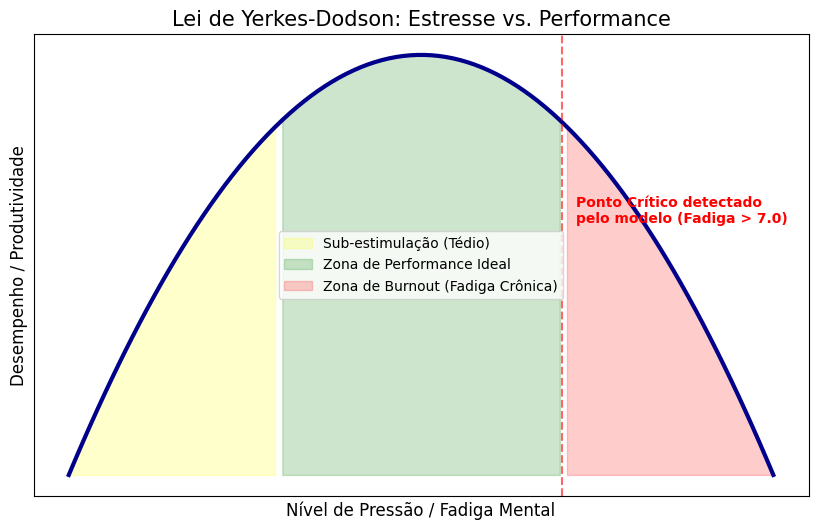

In [16]:
#Código para o Gráfico de Yerkes-Dodson
#Criando os dados para a curva (U-invertido)
x = np.linspace(0, 10, 100)
#Função quadrática para simular a performance
y = -0.1 * (x - 5)**2 + 2.5 

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='darkblue', lw=3)

#Colorindo as zonas de impacto
plt.fill_between(x, y, where=(x <= 3), color='yellow', alpha=0.2, label='Sub-estimulação (Tédio)')
plt.fill_between(x, y, where=((x > 3) & (x <= 7)), color='green', alpha=0.2, label='Zona de Performance Ideal')
plt.fill_between(x, y, where=(x > 7), color='red', alpha=0.2, label='Zona de Burnout (Fadiga Crônica)')

#Adicionando a linha do seu modelo
plt.axvline(x=7, color='red', linestyle='--', alpha=0.6)
plt.text(7.2, 1.5, 'Ponto Crítico detectado\npelo modelo (Fadiga > 7.0)', color='red', fontweight='bold')

#Estilização
plt.title('Lei de Yerkes-Dodson: Estresse vs. Performance', fontsize=15)
plt.xlabel('Nível de Pressão / Fadiga Mental', fontsize=12)
plt.ylabel('Desempenho / Produtividade', fontsize=12)
plt.xticks([]) 
plt.yticks([])
plt.legend()
plt.grid(False)

plt.show()

| **Fator**                 | **Impacto Relativo** | **Descrição**                                                          |
| ------------------------- | -------------------- | ---------------------------------------------------------------------- |
| Fadiga Mental             | 81.9%                | O maior preditor isolado. Reflete o cansaço cognitivo acumulado.       |
| Alocação de Recursos      | 9.2%                 | Refere-se à quantidade de ferramentas e projetos sob responsabilidade. |
| Antiguidade (Days Joined) | 5.7%                 | Funcionários com mais tempo de casa mostram um desgaste acumulado.     |

| **Conceito**      | **Implicação no Burnout**                          | **Intervenção Recomendada**                                 |
| ----------------- | -------------------------------------------------- | ----------------------------------------------------------- |
| Carga Cognitiva   | Fadiga mental bloqueia a inovação.                 | Limitar reuniões a 45 min para evitar exaustão pré-frontal. |
| Autonomia (WFH)   | Aumenta a resiliência ao estresse.                 | Manter políticas de flexibilidade de local e horário.       |
| Recuperação Ativa | O sono e o descanso não são luxos, são biológicos. | “Direito à desconexão” (não enviar e-mails após o horário). |

In [18]:
# 1. Configurando a estrutura com mais espaço (vertical_spacing aumentado)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>Acurácia:</b> Real vs. Previsto", 
        "<b>Impacto:</b> Importância das Variáveis",
        "<b>Gatilho:</b> Fadiga Mental x Burnout",
        "<b>Bem-estar:</b> Efeito do Home Office (WFH)"
    ),
    vertical_spacing=0.2,   # Aumenta o espaço entre as linhas
    horizontal_spacing=0.12 # Aumenta o espaço entre as colunas
)

# --- QUADRANTE 1: Histograma de Performance ---
fig.add_trace(
    go.Histogram(x=y_val, name='Dados Reais', marker_color='#3366CC', nbinsx=30),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=y_pred_otimizado, name='Predição Modelo', marker_color='#109618', nbinsx=30),
    row=1, col=1
)

# --- QUADRANTE 2: Importância das Variáveis ---
# Invertendo a ordem para o gráfico de barras horizontais ficar mais legível
rf_sorted = rf_importances.sort_values(by='Importância', ascending=True)
fig.add_trace(
    go.Bar(
        x=rf_sorted['Importância'], 
        y=rf_sorted['Atributo'], 
        orientation='h',
        marker=dict(color='#8884d8'),
        name='Peso no Modelo'
    ),
    row=1, col=2
)

# --- QUADRANTE 3: Fadiga vs Burnout (Scatter) ---
fig.add_trace(
    go.Scatter(
        x=train_clean['Mental Fatigue Score'].iloc[:800], # Amostra para não poluir
        y=train_clean['Burn Rate'].iloc[:800],
        mode='markers',
        marker=dict(
            size=6, 
            color=train_clean['Burn Rate'].iloc[:800], 
            colorscale='Viridis',
            opacity=0.6
        ),
        name='Funcionário Indiv.'
    ),
    row=2, col=1
)

# --- QUADRANTE 4: WFH Boxplot ---
fig.add_trace(go.Box(y=wfh_sim, name='Com WFH', marker_color='#00CC96', boxpoints='outliers'), row=2, col=2)
fig.add_trace(go.Box(y=wfh_nao, name='Sem WFH', marker_color='#EF553B', boxpoints='outliers'), row=2, col=2)

# 2. Ajustes de Layout para evitar interferências
fig.update_layout(
    title=dict(
        text="<b>Dashboard Executivo: Preditores de Burnout</b><br><span style='font-size:14px'>Modelo Random Forest Otimizado (R²: 0.90)</span>",
        x=0.5,
        xanchor='center'
    ),
    height=1000, # Aumentei a altura para dar mais espaço vertical
    width=1100,  # Largura confortável
    template="plotly_white",
    hovermode="closest",
    # Ajuste da legenda para fora da área dos gráficos
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.12, # Joga a legenda para baixo de tudo
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=50, r=50, t=120, b=100) # Margens internas generosas
)

# Atualizando nomes dos eixos individualmente para clareza
fig.update_xaxes(title_text="Taxa de Esgotamento", row=1, col=1)
fig.update_xaxes(title_text="Peso Estatístico", row=1, col=2)
fig.update_xaxes(title_text="Nota de Fadiga Mental", row=2, col=1)
fig.update_xaxes(title_text="Categoria", row=2, col=2)

fig.update_yaxes(title_text="Frequência", row=1, col=1)
fig.update_yaxes(title_text="Burn Rate", row=2, col=1)
fig.update_yaxes(title_text="Burn Rate", row=2, col=2)

fig.show()

In [19]:
# --- Preparação da Curva de Yerkes-Dodson ---
x_curve = np.linspace(0, 10, 100)
y_performance = -0.1 * (x_curve - 5)**2 + 2.5 # Função quadrática para o U-invertido

# 1. Configurando estrutura (3 linhas: 2x2 em cima, 1x1 embaixo para a curva)
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{}, {}],
           [{}, {}],
           [{"colspan": 2}, None]], # Curva de Yerkes ocupará a largura toda
    subplot_titles=(
        "<b>Acurácia:</b> Real vs. Previsto", "<b>Impacto:</b> Pesos do Modelo",
        "<b>Gatilho:</b> Fadiga x Burnout", "<b>Bem-estar:</b> Efeito WFH",
        "<b>Teoria de Performance:</b> Lei de Yerkes-Dodson (Estresse vs Produtividade)"
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# --- QUADRANTE 1: Histograma ---
fig.add_trace(go.Histogram(x=y_val, name='Real', marker_color='#3366CC'), row=1, col=1)
fig.add_trace(go.Histogram(x=y_pred_otimizado, name='Previsto', marker_color='#109618'), row=1, col=1)

# --- QUADRANTE 2: Importância ---
fig.add_trace(go.Bar(x=rf_sorted['Importância'], y=rf_sorted['Atributo'], orientation='h', marker_color='#8884d8', name='Importância'), row=1, col=2)

# --- QUADRANTE 3: Scatter ---
fig.add_trace(go.Scatter(x=train_clean['Mental Fatigue Score'].iloc[:800], y=train_clean['Burn Rate'].iloc[:800], mode='markers', marker=dict(size=6, color=train_clean['Burn Rate'].iloc[:800], colorscale='Viridis'), name='Funcionários'), row=2, col=1)

# --- QUADRANTE 4: WFH Boxplot ---
fig.add_trace(go.Box(y=wfh_sim, name='Com WFH', marker_color='#00CC96'), row=2, col=2)
fig.add_trace(go.Box(y=wfh_nao, name='Sem WFH', marker_color='#EF553B'), row=2, col=2)

# --- LINHA 3: Curva de Yerkes-Dodson (A Grande Finalização) ---
# Adicionando áreas coloridas (Zonas)
fig.add_trace(go.Scatter(x=x_curve[x_curve<=3], y=y_performance[x_curve<=3], fill='tozeroy', name='Sub-estimulação', line_color='gray', fillcolor='rgba(200, 200, 200, 0.2)'), row=3, col=1)
fig.add_trace(go.Scatter(x=x_curve[(x_curve>3) & (x_curve<=7)], y=y_performance[(x_curve>3) & (x_curve<=7)], fill='tozeroy', name='Performance Ideal', line_color='green', fillcolor='rgba(0, 255, 0, 0.1)'), row=3, col=1)
fig.add_trace(go.Scatter(x=x_curve[x_curve>7], y=y_performance[x_curve>7], fill='tozeroy', name='Zona de Burnout', line_color='red', fillcolor='rgba(255, 0, 0, 0.2)'), row=3, col=1)

# Linha de Inflexão (Baseada no seu modelo)
fig.add_shape(type="line", x0=7, y0=0, x1=7, y1=2.5, line=dict(color="Red", width=3, dash="dash"), row=3, col=1)

# 2. Ajustes Finais de Layout
fig.update_layout(
    title_text="<b>Dashboard Analítico de Burnout e Performance Humana</b>",
    height=1200, # Aumentado para 3 linhas de gráficos
    width=1100,
    template="plotly_white",
    legend=dict(orientation="h", y=-0.05, x=0.5, xanchor="center"),
    margin=dict(t=100, b=100)
)

# Ajuste específico de eixos para a Curva
fig.update_xaxes(title_text="Pressão / Fadiga Mental", row=3, col=1)
fig.update_yaxes(title_text="Desempenho", row=3, col=1, showticklabels=False)

fig.show()

# **Conclusão**

o Burnout não é apenas falta de motivação, mas sim o esgotamento biológico do Córtex Pré-Frontal. Uma vez nesta zona vermelha, a produtividade cai drasticamente, independentemente do esforço do funcionário.

# Tratamento não farmacológico (Reprogramando o Cérebro) - Usando a Neurociência
A neurociência demonstra que a privação de sono degrada o córtex pré-frontal, responsável pelas decisões e controle emocional. Manter entre 7 a 8 horas de sono consistentes.

Praticar o Single-tasking (tarefa única). Bloqueie notificações e estipule janelas específicas para checar e-mails/mensagens. Isso reduz a fragmentação da atenção, fortalecendo as redes neurais de foco profundo e reduzindo o índice de fadiga mental.

Pausas ativam a "Rede de Modo Padrão" (DMN), permitindo que o cérebro processe informações de forma subconsciente e reduza o escore de burnout.

A interação social libera oxitocina, que atua como um tampão natural contra o cortisol (hormônio do estresse), protegendo o hipocampo.

Praticar 30 minutos de atividade moderada ajuda a reduzir o índice de fadiga acumulada, prevenindo que o funcionário saia do risco "Baixo" para o "Alto". Priorizando atividades físicas em grupo ou esportes coletivos estimulam a liberação de ocitocina e dopamina. O exercício promove o BDNF (Fator Neurotrófico Derivado do Cérebro), que "repara" as conexões neuronais desgastadas pela sobrecarga cognitiva e melhora a taxa de conclusão de tarefas (task completion). Para funcionários que apresentam métricas de "Médio Risco", a introdução de atividades físicas programadas atua como uma intervenção de biofeedback, diminuindo o estresse oxidativo e reprogramando o cérebro para manter o foco e a estabilidade emocional sob pressão.

# **Nathália Sorg**